# Revenue Reconciliation
**Project 2 — Revenue & GTM Analytics**

Explains the four gaps in the B2B revenue chain:

```
CRM Bookings  →  Contract Value  →  Billed (USD)  →  Collected Cash
    Gap 1            Gap 2              Gap 3
 (discount)     (timing/partial)   (payment failure)
```

**Key questions:**
1. How large is each gap in absolute and percentage terms?
2. Which segment discounts the most at signing?
3. How much revenue is at risk due to pending/failed payments?
4. What is the cash collection rate by segment and revenue model?

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from mart_simulator import (
    build_fct_bookings, build_fct_revenue, build_stg_contracts
)

pd.set_option('display.float_format', '{:,.2f}'.format)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
bookings = build_fct_bookings()
revenue  = build_fct_revenue()
contracts_raw = build_stg_contracts()

print(f'Bookings (won opps):  {len(bookings):,} rows')
print(f'Revenue (invoices):   {len(revenue):,} rows')
print(f'Contract records:     {len(contracts_raw):,} (incl. duplicates)')

Bookings (won opps):  370 rows
Revenue (invoices):   1,725 rows
Contract records:     377 (incl. duplicates)


## 2. The Four Revenue Numbers

Top-line reconciliation: how much revenue is at each stage of the chain?

In [3]:
total_bookings   = bookings['crm_booking_amount'].sum()
total_contracted = bookings['contract_value'].sum()
total_billed     = bookings['total_billed_usd'].sum()
total_collected  = bookings['total_collected_usd'].sum()
total_at_risk    = bookings['total_at_risk_usd'].fillna(0).sum()
total_failed     = bookings['total_failed_usd'].fillna(0).sum()

chain = pd.DataFrame({
    'Revenue Stage': ['CRM Bookings', 'Contract Value', 'Billed (USD)', 'Collected Cash'],
    'Amount ($)': [total_bookings, total_contracted, total_billed, total_collected],
})
chain['vs Bookings'] = chain['Amount ($)'] / total_bookings
chain['Gap vs Prior ($)'] = chain['Amount ($)'].diff().fillna(0) * -1
chain['Gap vs Prior (%)'] = chain['vs Bookings'].diff().fillna(0) * -1

print('=== Revenue Chain Reconciliation ===')
display(chain.style
    .format({
        'Amount ($)': '${:,.0f}',
        'vs Bookings': '{:.1%}',
        'Gap vs Prior ($)': '${:,.0f}',
        'Gap vs Prior (%)': '{:.1%}'
    })
    .bar(subset=['Amount ($)'], color='#4C72B0')
)

=== Revenue Chain Reconciliation ===


,Revenue Stage,Amount ($),vs Bookings,Gap vs Prior ($),Gap vs Prior (%)
0,CRM Bookings,"$11,836,415",100.0%,$-0,-0.0%
1,Contract Value,"$11,784,331",99.6%,"$52,084",0.4%
2,Billed (USD),"$11,386,974",96.2%,"$397,356",3.4%
3,Collected Cash,"$9,661,659",81.6%,"$1,725,316",14.6%


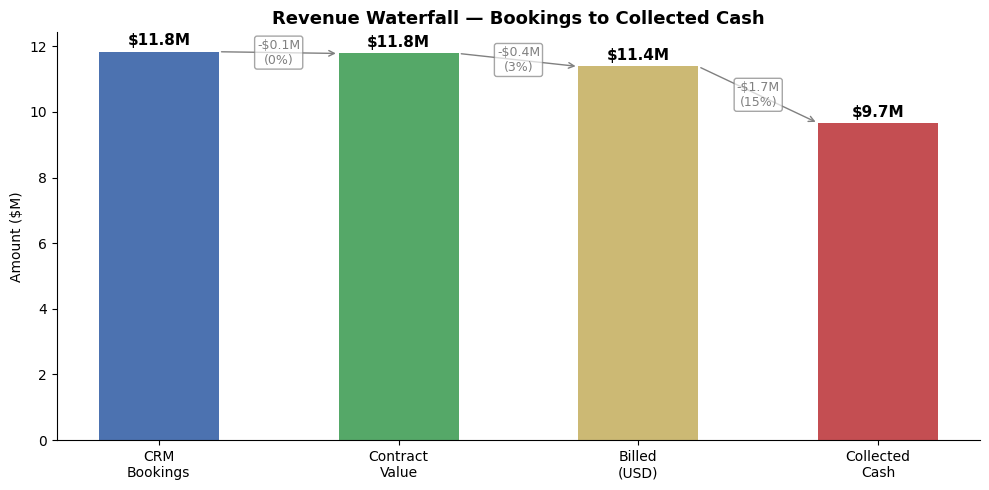

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

labels   = ['CRM\nBookings', 'Contract\nValue', 'Billed\n(USD)', 'Collected\nCash']
amounts  = [total_bookings, total_contracted, total_billed, total_collected]
colors   = ['#4C72B0', '#55A868', '#CCB974', '#C44E52']

bars = ax.bar(labels, [a/1e6 for a in amounts], color=colors, width=0.5)

for bar, amt in zip(bars, amounts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'${amt/1e6:.1f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Annotate gaps
for i in range(len(amounts)-1):
    gap = amounts[i] - amounts[i+1]
    mid_x = i + 0.5
    ax.annotate('', xy=(i+1-0.25, amounts[i+1]/1e6), xytext=(i+0.25, amounts[i]/1e6),
                arrowprops=dict(arrowstyle='->', color='gray'))
    ax.text(mid_x, (amounts[i] + amounts[i+1]) / 2 / 1e6,
            f'-${gap/1e6:.1f}M\n({gap/amounts[i]:.0%})',
            ha='center', va='center', fontsize=9, color='gray',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='gray', alpha=0.7))

ax.set_ylabel('Amount ($M)')
ax.set_title('Revenue Waterfall — Bookings to Collected Cash', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Gap 1 — Booking vs. Contract (Discount Analysis)

In [5]:
has_contract = bookings[bookings['has_contract']].copy()

discount_dist = has_contract['discount_tier'].value_counts().reset_index()
discount_dist.columns = ['discount_tier', 'count']
discount_dist['pct'] = discount_dist['count'] / discount_dist['count'].sum()

print('Discount tier distribution:')
display(discount_dist.style.format({'count': '{:,}', 'pct': '{:.1%}'}))

print('\nDiscount by segment:')
seg_discount = (
    has_contract.groupby('segment')
    .agg(
        deals=('opportunity_id', 'nunique'),
        total_bookings=('crm_booking_amount', 'sum'),
        total_contracted=('contract_value', 'sum'),
        avg_booking_to_contract_gap=('booking_to_contract_gap', 'mean'),
    )
    .reset_index()
)
seg_discount['avg_discount_pct'] = (
    (seg_discount['total_bookings'] - seg_discount['total_contracted'])
    / seg_discount['total_bookings']
)
display(seg_discount.style.format({
    'deals': '{:,}',
    'total_bookings': '${:,.0f}',
    'total_contracted': '${:,.0f}',
    'avg_booking_to_contract_gap': '${:,.0f}',
    'avg_discount_pct': '{:.1%}'
}).background_gradient(subset=['avg_discount_pct'], cmap='Reds'))

Discount tier distribution:


,discount_tier,count,pct
0,Contract Exceeds Booking,193,52.2%
1,Minor Discount (<5%),90,24.3%
2,Moderate Discount (5-15%),87,23.5%



Discount by segment:


,segment,deals,total_bookings,total_contracted,avg_booking_to_contract_gap,avg_discount_pct
0,Enterprise,75,"$5,533,522","$5,488,345",$602,0.8%
1,Mid-Market,138,"$4,085,744","$4,060,257",$185,0.6%
2,SMB,157,"$2,217,148","$2,235,729",$-118,-0.8%


## 4. Gap 3 — Billed vs. Collected (Payment Risk)

In [6]:
print('=== Payment Status Breakdown (invoice level) ===')
payment_dist = revenue.groupby('payment_status').agg(
    invoice_count=('invoice_id', 'nunique'),
    total_amount_usd=('billing_amount_usd', 'sum'),
).reset_index()
payment_dist['pct_invoices'] = payment_dist['invoice_count'] / payment_dist['invoice_count'].sum()
payment_dist['pct_value'] = payment_dist['total_amount_usd'] / payment_dist['total_amount_usd'].sum()

display(payment_dist.style.format({
    'invoice_count': '{:,}',
    'total_amount_usd': '${:,.0f}',
    'pct_invoices': '{:.1%}',
    'pct_value': '{:.1%}'
}))

print(f'\nAt-risk revenue (Pending + Failed): ${total_at_risk + total_failed:,.0f}')
print(f'  → Pending:  ${total_at_risk:,.0f}')
print(f'  → Failed:   ${total_failed:,.0f}')

=== Payment Status Breakdown (invoice level) ===


,payment_status,invoice_count,total_amount_usd,pct_invoices,pct_value
0,Failed,61,"$356,012",3.5%,3.1%
1,Paid,"1,525","$9,693,782",88.4%,84.8%
2,Pending,139,"$1,375,164",8.1%,12.0%



At-risk revenue (Pending + Failed): $1,725,316
  → Pending:  $1,369,303
  → Failed:   $356,012


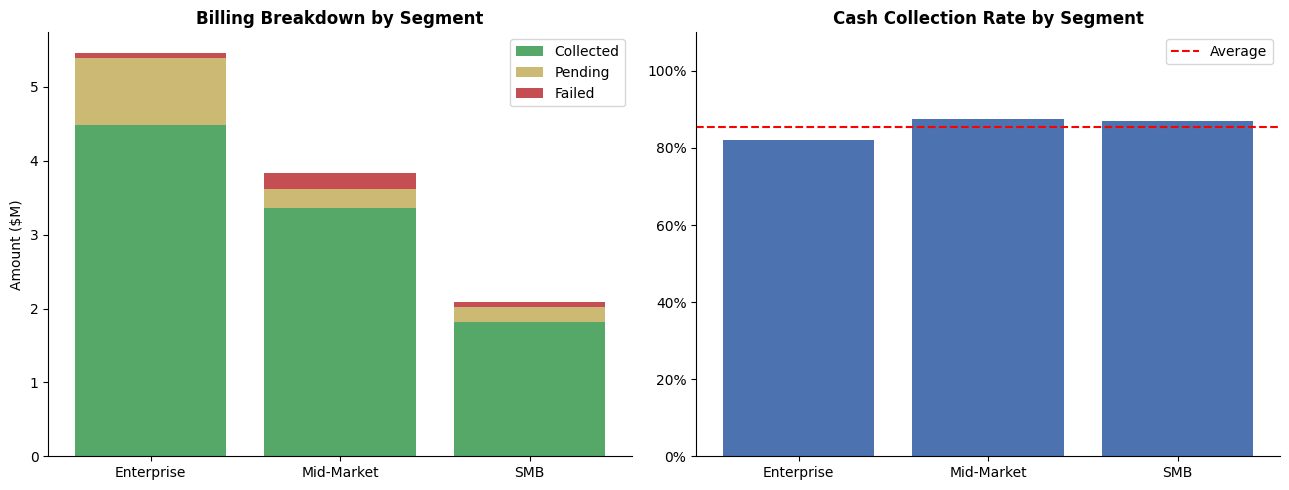

In [7]:
# Payment breakdown by segment
seg_payment = revenue.groupby('segment').agg(
    total_billed=('billing_amount_usd', 'sum'),
    total_collected=('collected_amount_usd', 'sum'),
    total_failed=('failed_amount_usd', 'sum'),
    total_at_risk=('at_risk_amount_usd', 'sum'),
).reset_index()
seg_payment['collection_rate'] = seg_payment['total_collected'] / seg_payment['total_billed']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar: billed breakdown
segs = seg_payment['segment']
axes[0].bar(segs, seg_payment['total_collected']/1e6, label='Collected', color='#55A868')
axes[0].bar(segs, seg_payment['total_at_risk']/1e6, bottom=seg_payment['total_collected']/1e6, label='Pending', color='#CCB974')
axes[0].bar(segs, seg_payment['total_failed']/1e6,
            bottom=(seg_payment['total_collected'] + seg_payment['total_at_risk'])/1e6,
            label='Failed', color='#C44E52')
axes[0].set_ylabel('Amount ($M)')
axes[0].set_title('Billing Breakdown by Segment', fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Collection rate
axes[1].bar(segs, seg_payment['collection_rate'], color='#4C72B0')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_ylim(0, 1.1)
axes[1].axhline(y=seg_payment['collection_rate'].mean(), color='red', linestyle='--', label='Average')
axes[1].set_title('Cash Collection Rate by Segment', fontweight='bold')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Duplicate Contract Issue

4 contract_ids appear twice with conflicting values — a data quality issue noted in exploration.

In [8]:
dupes = contracts_raw[contracts_raw['has_duplicate_contract_id']].sort_values('contract_id')
print(f'Duplicate contract records: {len(dupes)} rows ({dupes["contract_id"].nunique()} unique contract_ids)\n')

if len(dupes) > 0:
    dupe_comparison = dupes.groupby('contract_id').agg(
        values=('contract_value', list),
        statuses=('contract_status', list),
        value_delta=('contract_value', lambda x: x.max() - x.min())
    ).reset_index()
    display(dupe_comparison)
    print(f'\nMax value difference within a duplicate pair: ${dupe_comparison["value_delta"].max():,.0f}')
    print('dbt handling: is_canonical_record = TRUE picks the higher-value record for revenue calcs.')

Duplicate contract records: 8 rows (4 unique contract_ids)



,contract_id,values,statuses,value_delta
0,CON_000055,"[8604.1, 8470.67]","[Active, Active]",133.43
1,CON_000103,"[478340.25, 477752.54]","[Active, Active]",587.71
2,CON_000151,"[43168.41, 42472.89]","[Cancelled, Cancelled]",695.52
3,CON_000355,"[3103.81, 3062.86]","[Active, Active]",40.95



Max value difference within a duplicate pair: $696
dbt handling: is_canonical_record = TRUE picks the higher-value record for revenue calcs.


## 6. Revenue by Month

Monthly billing trend — collected vs. at risk.

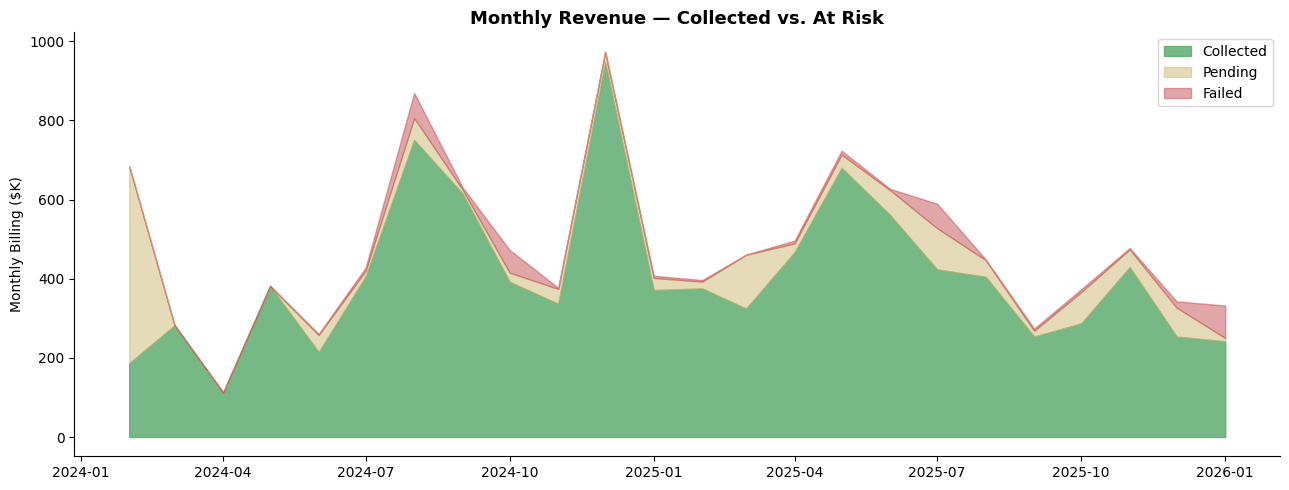

Last 3 months avg collected: $308,172/mo
Last 3 months avg at-risk:   $42,140/mo


In [9]:
monthly = revenue.groupby(['billing_year', 'billing_month']).agg(
    billed=('billing_amount_usd', 'sum'),
    collected=('collected_amount_usd', 'sum'),
    at_risk=('at_risk_amount_usd', 'sum'),
    failed=('failed_amount_usd', 'sum'),
).reset_index()
monthly['period'] = pd.to_datetime(
    monthly['billing_year'].astype(str) + '-' + monthly['billing_month'].astype(str).str.zfill(2)
)
monthly = monthly.sort_values('period')

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(monthly['period'], monthly['collected']/1e3, alpha=0.8, color='#55A868', label='Collected')
ax.fill_between(monthly['period'], monthly['at_risk']/1e3 + monthly['collected']/1e3,
                monthly['collected']/1e3, alpha=0.5, color='#CCB974', label='Pending')
ax.fill_between(monthly['period'],
                monthly['at_risk']/1e3 + monthly['collected']/1e3 + monthly['failed']/1e3,
                monthly['at_risk']/1e3 + monthly['collected']/1e3, alpha=0.5, color='#C44E52', label='Failed')

ax.set_ylabel('Monthly Billing ($K)')
ax.set_title('Monthly Revenue — Collected vs. At Risk', fontsize=13, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

recent = monthly.tail(3)
print(f'Last 3 months avg collected: ${recent["collected"].mean():,.0f}/mo')
print(f'Last 3 months avg at-risk:   ${recent["at_risk"].mean():,.0f}/mo')

## 7. Summary — Key Findings

In [10]:
gap1_pct = (total_bookings - total_contracted) / total_bookings
gap2_pct = (total_contracted - total_billed) / total_contracted if total_contracted > 0 else 0
gap3_pct = (total_billed - total_collected) / total_billed if total_billed > 0 else 0
e2e_rate = total_collected / total_bookings

print('=' * 58)
print('  REVENUE RECONCILIATION — KEY FINDINGS')
print('=' * 58)
print(f'  CRM Bookings:          ${total_bookings:>12,.0f}   (100%)')
print(f'  Contract Value:        ${total_contracted:>12,.0f}   ({1-gap1_pct:.0%}) [{gap1_pct:.1%} gap]')
print(f'  Billed (USD):          ${total_billed:>12,.0f}   ({total_billed/total_bookings:.0%}) [{gap2_pct:.1%} gap]')
print(f'  Collected Cash:        ${total_collected:>12,.0f}   ({total_collected/total_bookings:.0%}) [{gap3_pct:.1%} gap]')
print(f'  End-to-end rate:       {e2e_rate:.1%}')
print(f'  At risk (Pending):     ${total_at_risk:>12,.0f}')
print(f'  At risk (Failed):      ${total_failed:>12,.0f}')
print(f'  Duplicate contracts:   {contracts_raw["has_duplicate_contract_id"].sum()} records ({contracts_raw["contract_id"][contracts_raw["has_duplicate_contract_id"]].nunique()} IDs)')
print('=' * 58)
print('\ndbt models: int_revenue_lifecycle → fct_bookings, fct_revenue')

  REVENUE RECONCILIATION — KEY FINDINGS
  CRM Bookings:          $  11,836,415   (100%)
  Contract Value:        $  11,784,331   (100%) [0.4% gap]
  Billed (USD):          $  11,386,974   (96%) [3.4% gap]
  Collected Cash:        $   9,661,659   (82%) [15.2% gap]
  End-to-end rate:       81.6%
  At risk (Pending):     $   1,369,303
  At risk (Failed):      $     356,012
  Duplicate contracts:   8 records (4 IDs)

dbt models: int_revenue_lifecycle → fct_bookings, fct_revenue
